# Notebook 7.2: Evaluation Libraries — PyFolio and QuantStats



## Financial Trading with Python, 2nd Edition

---

In Notebook 7.1, we built every performance metric from scratch. That exercise was essential: you now understand what each number means, how it is calculated, and where the assumptions live. But you would not want to rebuild all of that code every time you evaluate a strategy. That is what libraries are for.

This notebook introduces two professional-grade evaluation libraries: PyFolio and QuantStats. Both take a return series as input and produce comprehensive performance reports, tear sheets, and visualizations. We apply them to the same 50/200 SMA crossover strategy from Notebook 7.1 so you can verify the numbers against what we calculated manually. We then apply them to the VIXY tail hedge baseline from Chapter 6 to connect back to our case study.

This notebook covers:

- PyFolio: generating and interpreting an institutional-grade tear sheet
- QuantStats: generating an HTML report and using standalone metric functions
- Where the two libraries agree, where they differ, and when to use which
- Applying both libraries to the VIXY tail hedge strategy

In [1]:
# --- Install evaluation libraries with pinned versions ---
# PyFolio: originally developed by Quantopian, now community-maintained.
# QuantStats: actively maintained, modern API, HTML report export.
# We pin versions to ensure reproducibility as Colab updates.
# Ignore compatibility issues. They will not affect this notebook.

!pip install pyfolio-reloaded==0.9.5 quantstats==0.0.64 --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 50.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.7/78.7 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 63.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-pyt

In [1]:
# Please restart the runtime after we installed those packages:
# Runtime --> Restart Session

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyfolio as pf
import quantstats as qs
import warnings

warnings.filterwarnings('ignore')
sns.set_theme()

pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.4f}'.format)

print(f"PyFolio version:    {pf.__version__}")
print(f"QuantStats version: {qs.__version__}")

/usr/local/lib/python3.12/dist-packages/pyfolio/pos.py:25: UserWarning: Module "zipline.assets" not found; multipliers will not be applied to position notionals.
  warnings.warn(


PyFolio version:    0.9.5
QuantStats version: 0.0.64


### 1.1 Loading Data and Rebuilding the Teaching Strategy

We reload the case study data and rebuild the 50/200 SMA crossover strategy from Notebook 7.1. We also load the VIXY strategy returns from Chapter 6 for use later in this notebook. Each notebook should be self-contained so you can run it without dependencies on prior notebooks.

In [3]:
# --- Load case study data ---
df_prices = pd.read_parquet('case_study_prices.parquet')
df_returns = df_prices.pct_change().dropna()

# --- Rebuild the 50/200 SMA crossover strategy ---
# (Same logic as Notebook 7.1 Section 2)
sma_50 = df_prices['SPY'].rolling(window=50).mean()
sma_200 = df_prices['SPY'].rolling(window=200).mean()

# Signal: long SPY when SMA50 > SMA200, hold BIL otherwise
signal = (sma_50 > sma_200).astype(int)

# --- Build daily weights ---
# The weights represent our portfolio allocation on each date.
# SPY = 1.0 means 100% invested in SPY; BIL = 1.0 means 100% in cash.
# Weights always sum to 1.0 (fully invested, no leverage).
df_weights = pd.DataFrame(index=df_prices.index)
df_weights['SPY'] = signal
df_weights['BIL'] = 1 - signal
df_weights = df_weights.dropna()

# --- Calculate portfolio returns using lagged weights ---
#
# This is the most important step to get right. The goal is to
# calculate what the portfolio earned each day, given the allocation
# we held going into that day.
#
# WHY we need index alignment:
# df_weights and df_returns may not have identical date indices.
# Weights start after a 200-day warmup period. Returns start one day
# after prices (because pct_change needs two days). We find the dates
# that exist in both, so every weight has a matching return.
common_idx = df_weights.index.intersection(df_returns.index)

# WHY we lag the weights by one day:
# On any given day, we only know the signal AFTER the market closes
# (because the signal uses that day's closing price to compute the SMAs).
# So the earliest we can act on today's signal is tomorrow's open.
# Shifting weights forward by one day simulates this: today's portfolio
# return uses YESTERDAY's weights applied to TODAY's asset returns.
# Without this shift, we would be using information we did not yet have
# to set our allocation — that is lookahead bias.
w_lagged = df_weights.loc[common_idx].shift(1).dropna()

# WHY we re-align returns to the lagged weight dates:
# The shift created one NaN row at the start (the first date has no
# "yesterday" weight). After dropping that NaN, the weight index is
# one day shorter. We slice the returns to match exactly, so every
# row has a weight and a return for the same date.
r_aligned = df_returns[['SPY', 'BIL']].loc[w_lagged.index]

# --- Daily portfolio return ---
# For each day: (weight_SPY * return_SPY) + (weight_BIL * return_BIL)
# This is the weighted average of asset returns using yesterday's allocation.
strategy_returns = (w_lagged * r_aligned).sum(axis=1)
strategy_returns.name = 'SMA_Crossover'

# SPY buy-and-hold benchmark: 100% SPY every day, no signal needed
benchmark_returns = r_aligned['SPY'].copy()
benchmark_returns.name = 'SPY_Buy_Hold'

print(f"Strategy period: {strategy_returns.index[0].strftime('%Y-%m-%d')} to "
      f"{strategy_returns.index[-1].strftime('%Y-%m-%d')}")
print(f"Trading days: {len(strategy_returns)}")

Strategy period: 2011-01-06 to 2025-12-31
Trading days: 3769


Good. Same date range and trading day count as Notebook 7.1. We are working with identical data.

Both PyFolio and QuantStats expect daily return series as their primary input. Some functions also accept a benchmark return series for relative performance analysis. Our `strategy_returns` and `benchmark_returns` variables are already in the right format.

## Section 2: PyFolio

### 2.1 What Is PyFolio?

PyFolio was originally developed by Quantopian, the algorithmic trading platform that shut down in 2020. It was designed to produce the kind of tear sheet that institutional portfolio managers use to evaluate strategies: a dense, multi-page report covering returns, risk, drawdowns, and exposure analysis.

After Quantopian closed, the community forked the project as `pyfolio-reloaded` to maintain compatibility with newer versions of pandas and Python. It works, but development is slow and you will occasionally see deprecation warnings. We use it here because the tear sheet format remains one of the best single-view summaries of strategy performance, and because you will encounter PyFolio output in research papers, blog posts, and open-source strategy repositories.

PyFolio's core function is `pf.create_returns_tear_sheet()`. You pass in a daily return series, optionally a benchmark, and it produces a full report. Let us start with the basic version and walk through what it shows.

Start date,2011-01-06
End date,2025-12-31
Total months,179
,Backtest
Annual return,9.585%
Cumulative returns,293.145%
Annual volatility,13.815%
Sharpe ratio,0.73
Calmar ratio,0.28
Stability,0.95
Max drawdown,-33.717%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,33.72,2020-02-19,2020-03-23,2021-04-09,298
1,19.20,2015-07-20,2016-06-27,2017-06-01,489
2,18.76,2025-02-19,2025-04-08,NaT,NaN
3,12.87,2022-01-03,2022-03-08,2023-06-13,377
4,10.73,2018-09-20,2019-06-03,2019-11-01,292


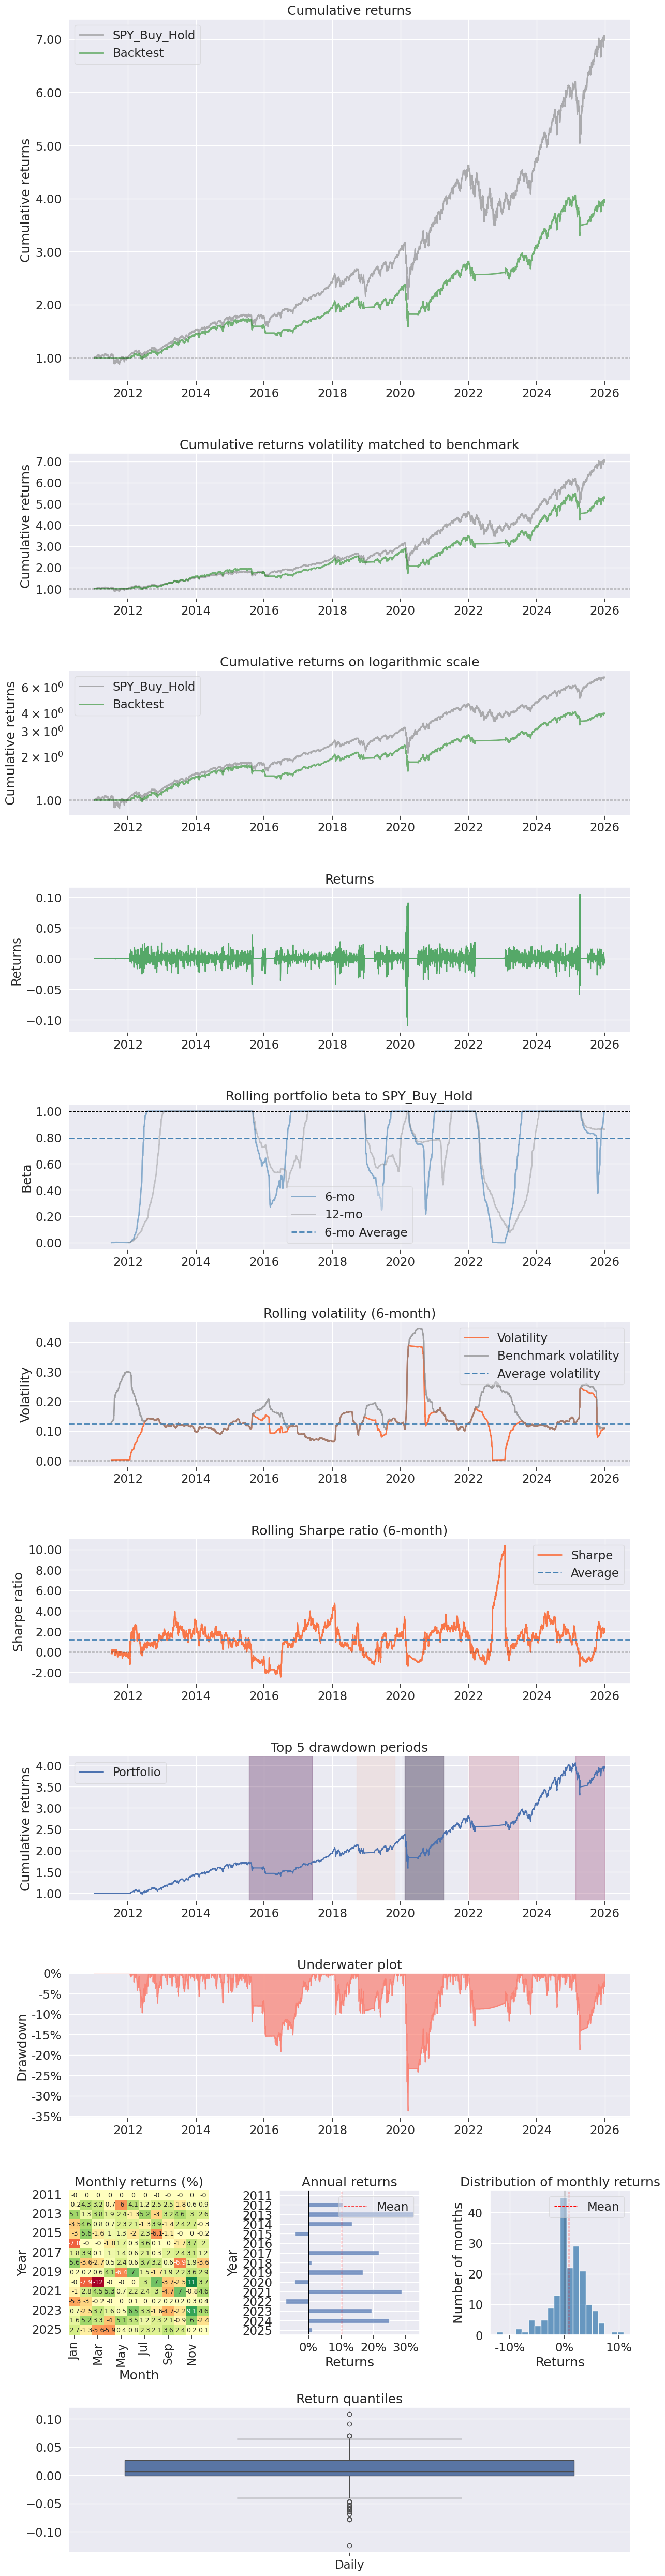

In [4]:
# --- PyFolio Basic Tear Sheet ---
# PyFolio expects a daily return series with a DatetimeIndex.
# Our strategy_returns already meets this requirement.
#
# The benchmark_rets parameter accepts a daily return series for
# relative performance analysis. We pass in SPY buy-and-hold.
#
# Note: PyFolio may produce deprecation warnings from pandas or
# matplotlib. These are cosmetic and do not affect the output.

pf.create_returns_tear_sheet(strategy_returns, benchmark_rets=benchmark_returns)

That's a lot of information and visuals!

PyFolio produces a statistics summary and a worst drawdowns table in one call. Before we look at the charts, we need to compare these numbers against what we calculated in Notebook 7.1. The metrics should be close, but some will not match exactly, and the differences matter.

**What matches:**
- Annual return: PyFolio says 9.585%, we calculated 9.59%. Effectively identical, just rounding.
- Annual volatility: PyFolio says 13.815%, we calculated 13.81%. Same story.
- Max drawdown: PyFolio says -33.717%, we calculated -33.72%. Match.
- Calmar ratio: PyFolio says 0.28, we calculated 0.284. Match.
- The worst drawdowns table matches our top-5 episode analysis exactly: same dates, same depths, same durations. The 2025 drawdown shows NaT (Not a Time) for the recovery date because it was still ongoing at the end of the data.

**What does not match, and why:**

The Sharpe ratio is the most visible difference. PyFolio reports 0.73. We calculated 0.694. That is not a rounding difference. It comes from two methodology choices that vary across the industry.

First, the annualization method. Our Notebook 7.1 calculation used CAGR (geometric annualized return) divided by annualized volatility. PyFolio uses arithmetic annualized return (mean daily return multiplied by 252) divided by annualized volatility (daily standard deviation multiplied by sqrt(252)). The arithmetic mean is always higher than the geometric mean because it does not account for the compounding drag of volatility. On a return series with 13.8% volatility over 15 years, the gap between arithmetic and geometric annualization is enough to move the Sharpe meaningfully.

Second, the risk-free rate. Both our calculation and PyFolio default to a risk-free rate of zero. This is the most common practitioner convention, and it is what most libraries use out of the box. But it is not universal. Some calculations subtract the prevailing T-bill rate or the fed funds rate from the strategy return before dividing by volatility. During periods of near-zero interest rates (2011-2021), the difference is negligible. During periods of higher rates (2022-2025, when short-term rates exceeded 4%), it matters considerably. A strategy returning 9% with a 5% risk-free rate has a very different Sharpe ratio than the same strategy measured against a zero risk-free rate. When you see a Sharpe ratio from any source, always ask: what risk-free rate did they use?

The Sortino ratio shows similar discrepancies. PyFolio reports 1.02, we calculated 0.963. The arithmetic vs geometric difference in the numerator carries through, and there are also differences in how PyFolio calculates downside deviation. Some implementations use the full return series (replacing positive returns with zero), others use only the negative returns. Both are defensible, but they give different numbers.

**Why this matters:**

This is not an academic footnote. If you calculate a Sharpe ratio of 0.694 from scratch and then run PyFolio and see 0.73, you might think you made an error. You did not. You used a different convention. The same thing will happen when you compare output from different libraries, research papers, or fund fact sheets. The label says "Sharpe ratio" but the calculation behind it can vary. The lesson: never compare risk-adjusted metrics across sources unless you know the methodology behind each one. A Sharpe ratio is not a Sharpe ratio is not a Sharpe ratio. When we run QuantStats in the next section, we will see yet another set of numbers for the same return series, and the differences will again come down to conventions.

**Additional metrics worth noting:**

PyFolio reports several metrics we did not build in Notebook 7.1. You do not need to memorize these, but you should know what they mean when you see them.

- **Stability (0.95):** the R-squared of a linear regression on cumulative log returns. Values close to 1.0 mean the equity curve is close to a straight line. Our 0.95 is high, meaning the strategy grew fairly steadily despite the drawdowns.
- **Omega ratio (1.17):** the ratio of total gains above a threshold (zero) to total losses below it. Greater than 1.0 means more upside than downside in aggregate. It is related to the profit factor we calculated in Notebook 7.1 but uses daily returns rather than monthly.
- **Skew (-0.51) and Kurtosis (27.30):** the third and fourth moments of the return distribution. Negative skew means the left tail (large losses) is fatter than the right tail. Kurtosis of 27.30 is extremely high (a normal distribution has kurtosis of 3.0), confirming that this strategy has fat tails. Both numbers are reminders that the Sharpe ratio, which assumes normally distributed returns, understates the true risk.
- **Alpha (0.01) and Beta (0.65):** from a regression of strategy returns against benchmark returns. Beta of 0.65 means the strategy captures about 65% of SPY's daily moves, consistent with being in cash 21% of the time. Alpha of 0.01 is effectively zero, meaning the strategy adds no return beyond what its market exposure alone would predict.

Now let us look at the charts PyFolio generated.

### 2.2 Reading the PyFolio Tear Sheet

PyFolio generates twelve charts in a single call. This is one of its strengths: you get a comprehensive visual evaluation without writing any plotting code. But twelve charts can be overwhelming the first time you see them. Here is what to focus on.

**Cumulative returns (top three plots).** The first chart is the equity curve we already built in Notebook 7.1: strategy (green) trails SPY (gray). The second chart, "volatility matched to benchmark," scales the strategy returns so its volatility matches SPY's. This answers the question: if we leveraged the strategy up to match SPY's risk, would it have earned comparable returns? The two lines are closer here, but SPY still wins. The third chart shows the same equity curves on a logarithmic scale, where constant percentage growth appears as a straight line. Both lines are fairly straight, confirming steady compounding despite the drawdowns.

**Returns (daily bar chart).** The fourth chart plots each day's return as a vertical bar. The gaps where the bars nearly disappear are the BIL periods when the strategy was in cash. The COVID crash in early 2020 is the obvious spike downward. This chart is useful for spotting outlier days and confirming that the strategy is actually trading, not sitting flat.

**Rolling portfolio beta.** This shows how the strategy's exposure to SPY changes over time. The beta swings between near-zero (when the strategy is in BIL) and roughly 1.0 (when it is long SPY). The average of 0.65 makes sense: the strategy is in SPY about 79% of the time. This chart is particularly useful for strategies with variable market exposure. A steady beta means consistent market risk. A swinging beta, like ours, means the strategy is actively changing its risk profile.

**Rolling volatility (6-month).** The strategy's volatility (orange) drops to near-zero during cash periods and spikes during the COVID crash. The benchmark volatility (blue) stays more consistent because SPY is always fully invested. The COVID spike above 0.40 (40% annualized volatility) is a stark reminder of how extreme that period was.

**Rolling Sharpe ratio (6-month).** This is the same concept as our 12-month rolling Sharpe from Notebook 7.1, but with a shorter window. The shorter window makes it choppier and more reactive. Values swing between -2.0 and 10.0, reinforcing our earlier point: a single Sharpe ratio for the full period is an average of wildly different experiences.

**Top 5 drawdown periods.** The equity curve with the five worst drawdown episodes shaded in different colors. This is a visual version of our drawdown episodes table. The shading makes it easy to see how much of the 15-year period the strategy spent recovering from its worst declines.

**Underwater plot.** This is the drawdown curve we built in Notebook 7.1. The COVID trough at -33.7% dominates the chart. The strategy spends a meaningful portion of its life underwater, which is normal for any long-equity strategy.

**Monthly returns heatmap, annual returns bar chart, and return distribution.** The bottom row gives three views of the return distribution. The heatmap shows individual monthly returns color-coded (green for positive, red for negative). The annual bar chart shows yearly performance. The histogram confirms the fat-tailed distribution we saw in the kurtosis statistic (27.30): most daily returns cluster near zero, but the tails extend much further than a normal distribution would predict.

**Return quantiles (box plot).** The final chart shows the distribution of daily returns as a box plot. The whiskers and outlier dots confirm the fat tails. The median is slightly positive (expected for a strategy that is long SPY most of the time), but the range of outcomes on any single day is wide.

This is what you get from a single function call. The trade-off is that you have limited control over formatting and chart style. PyFolio is opinionated about its output: you get what it gives you. For quick evaluation and standardized reporting, that is a feature. For customized analysis or publication-quality charts, you will want to build your own plots or use QuantStats, which offers more flexibility.

*Note: It is a lot of information coming from one call and you have little control over the output and how things are calculated. This is a main reason why I built my own tear sheet over the years. I like to have control, and there are many metrics that I use to evaluate performance that are not found in these packages.*

### 2.3 PyFolio Limitations

PyFolio has some practical limitations worth knowing about before you adopt it as your primary tool.

First, as we just saw, the statistics table only shows the strategy. There is no side-by-side comparison with the benchmark. The benchmark appears on the charts and feeds into alpha and beta, but if you want the same summary statistics for SPY buy-and-hold, you need to run the tear sheet a second time with the benchmark as the input. This makes quick comparisons awkward.

Second, PyFolio is effectively unmaintained. The `pyfolio-reloaded` fork keeps it functional with newer Python and pandas versions, but active feature development has stopped. You will see deprecation warnings, and future pandas releases may break it entirely.

Third, the output format is fixed. You cannot easily extract individual charts, change the layout, or customize the styling. For a standardized internal report this is fine. For a client presentation or publication, you will want more control.

These are not reasons to avoid PyFolio. The tear sheet format is genuinely useful, the output is comprehensive, and it remains the most recognized evaluation format in the open-source quant community. But you should know what you are getting.

## Section 3: QuantStats

### 3.1 What Is QuantStats?

QuantStats is an actively maintained library built specifically for strategy evaluation. It was developed as a modern alternative to PyFolio, with a cleaner API, HTML report export, and fewer dependency issues. It is the library you are more likely to use in day-to-day work.

QuantStats has three modules: `qs.stats` for individual metric calculations, `qs.plots` for standalone charts, and `qs.reports` for full tear sheets. We will start with the HTML report (the equivalent of PyFolio's tear sheet), then explore the standalone functions that make QuantStats particularly useful for quick analysis.

In [6]:
# --- QuantStats HTML Report ---
# qs.reports.html() generates a complete strategy evaluation as an
# HTML file that you can open in any browser. This is one of
# QuantStats' best features: a shareable, self-contained report
# that does not require Python to view.
#
# Parameters:
#   - strategy_returns: daily return series (same as PyFolio)
#   - benchmark: daily benchmark return series
#   - title: report title shown at the top of the HTML page
#   - output: file path to save the HTML report
#
# The report includes: summary statistics, monthly returns heatmap,
# drawdown analysis, rolling metrics, and return distribution plots.

# --- Suppress QuantStats font warnings ---
# QuantStats tries to use Arial, which is not installed in Colab.
# It falls back to the default font automatically, but logs a warning
# for every single text element in every chart. This suppresses them.
import logging
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

qs.reports.html(strategy_returns,
                benchmark=benchmark_returns,
                title='50/200 SMA Crossover Strategy',
                output='sma_crossover_report.html')

print("Report saved to: sma_crossover_report.html")
print("Download and open in a browser to view the full report.")

# The file is saved in the Colab files section. If you don't download it,
# it will be lost when the Colab instance is terminated.

Report saved to: sma_crossover_report.html
Download and open in a browser to view the full report.


### 3.2 Reading the QuantStats Report

The HTML report is saved as a file you can open in any browser and share with anyone, no Python required. This is one of QuantStats' most practical features. But before you share it, you need to understand what it is telling you, and where it disagrees with what we have already calculated.

**The side-by-side format.** The first thing you notice is that QuantStats shows strategy and benchmark statistics in adjacent columns. This is a significant improvement over PyFolio, which only shows the strategy. You can immediately compare every metric without running anything twice.

**Where the numbers match our calculations and PyFolio:**
- Cumulative return: 293.14% for the strategy. Matches exactly.
- Max drawdown: -33.72% for both. Matches exactly.
- Annual volatility: 13.82% for the strategy, 17.17% for SPY. Matches.
- Sharpe: 0.73 for the strategy, 0.84 for SPY. The strategy Sharpe matches PyFolio. SPY's 0.84 is slightly higher than PyFolio's 0.808 because QuantStats and PyFolio use slightly different arithmetic annualization.

**Where the numbers do not match, and why you should care:**

The biggest discrepancy is the CAGR row. QuantStats reports CAGR of 6.51% for the strategy and 9.37% for SPY. We calculated 9.59% and 13.88% respectively. PyFolio reported 9.585% and did not show the benchmark. These are large differences, not rounding issues.

The culprit is likely a difference in how QuantStats annualizes compound returns. However, look further down the same table: the "Expected Yearly" row shows 9.56% for the strategy and 13.85% for SPY, which are nearly identical to our Notebook 7.1 calculations. Same library, same data, two different rows claiming to show annualized return, two very different numbers.

This is exactly why we built the metrics from scratch in Notebook 7.1. If you had only seen the QuantStats CAGR of 6.51%, you might have dismissed this strategy even more quickly than the data warrants. If you had only seen the Expected Yearly of 9.56%, you would have had a number consistent with our manual calculation. Without understanding the methodology behind each row, you cannot tell which one to trust. The answer is: trust the one whose calculation you understand and can verify.

**The Calmar ratio** also differs. QuantStats reports 0.19 for the strategy versus our 0.284 and PyFolio's 0.28. This follows directly from the CAGR discrepancy: the Calmar ratio is annualized return divided by maximum drawdown, so a lower annualized return produces a lower Calmar.

**Metrics unique to QuantStats worth knowing about:**
- **Smart Sharpe and Smart Sortino:** adjust for autocorrelation in returns. Daily returns are not truly independent (yesterday's big move increases the chance of a big move today), and the standard Sharpe ignores this. The Smart variants correct for it, which is why they are lower than the standard versions.
- **Kelly Criterion (8.97%):** the theoretically optimal fraction of capital to bet on this strategy, based on the win rate and payoff ratio. In practice, most practitioners use half-Kelly or less because the assumptions behind the formula are unrealistic.
- **Probabilistic Sharpe Ratio (99.73%):** the probability that the true Sharpe ratio is greater than zero, given the observed returns and sample size. A high value means we can be fairly confident the strategy has a positive Sharpe, but it says nothing about how high that Sharpe actually is.
- **Serenity Index (1.24 for strategy vs 2.99 for SPY):** a composite measure of the smoothness of the equity curve. Higher is better. SPY wins because its equity curve, despite deeper drawdowns, spends less time recovering.

**The annual returns table** at the bottom is particularly useful. It shows that the crossover strategy matched SPY exactly in years when the signal stayed long all year (2013, 2014, 2017, 2021, 2024) and trailed in years when it moved to cash (2015, 2016, 2019, 2020). The "Won" column makes this immediately visible. The strategy won in only 7 of 15 years, confirming that the cash periods cost more than they saved in most years.

### 3.3 QuantStats Standalone Functions

The HTML report is useful for a comprehensive overview, but in day-to-day work you will more often want individual metrics. QuantStats exposes every calculation as a standalone function through the `qs.stats` and `qs.plots` modules. This is where the library earns its place in your workflow: you can call a single function to get one number without generating a full report.

In [7]:
# --- QuantStats standalone metric functions ---
# These are the functions you will use most often in practice.
# Each one takes a daily return series and returns a single value.
# Some accept an optional benchmark series for relative metrics.

print("QuantStats Standalone Metrics: 50/200 SMA Crossover")
print("=" * 60)

# --- Return metrics ---
print(f"\nCumulative return:     "
      f"{qs.stats.comp(strategy_returns):.2%}")
print(f"CAGR:                  "
      f"{qs.stats.cagr(strategy_returns):.2%}")

# --- Risk metrics ---
print(f"Volatility (ann.):     "
      f"{qs.stats.volatility(strategy_returns):.2%}")
print(f"Max drawdown:          "
      f"{qs.stats.max_drawdown(strategy_returns):.2%}")

# --- Risk-adjusted metrics ---
# rf=0 sets the risk-free rate to zero, matching our convention
print(f"Sharpe ratio:          "
      f"{qs.stats.sharpe(strategy_returns, rf=0):.3f}")
print(f"Sortino ratio:         "
      f"{qs.stats.sortino(strategy_returns, rf=0):.3f}")
print(f"Calmar ratio:          "
      f"{qs.stats.calmar(strategy_returns):.3f}")

# --- Relative metrics (require a benchmark) ---
print(f"Information ratio:     "
      f"{qs.stats.information_ratio(strategy_returns, benchmark_returns):.3f}")

# --- Additional useful metrics ---
print(f"Skew:                  "
      f"{qs.stats.skew(strategy_returns):.3f}")
print(f"Kurtosis:              "
      f"{qs.stats.kurtosis(strategy_returns):.3f}")
print(f"Value at Risk (95%):   "
      f"{qs.stats.value_at_risk(strategy_returns):.2%}")

# --- Compare with benchmark ---
print(f"\n\nQuantStats Standalone Metrics: SPY Buy & Hold")
print("=" * 60)
print(f"\nCumulative return:     "
      f"{qs.stats.comp(benchmark_returns):.2%}")
print(f"CAGR:                  "
      f"{qs.stats.cagr(benchmark_returns):.2%}")
print(f"Volatility (ann.):     "
      f"{qs.stats.volatility(benchmark_returns):.2%}")
print(f"Max drawdown:          "
      f"{qs.stats.max_drawdown(benchmark_returns):.2%}")
print(f"Sharpe ratio:          "
      f"{qs.stats.sharpe(benchmark_returns, rf=0):.3f}")
print(f"Sortino ratio:         "
      f"{qs.stats.sortino(benchmark_returns, rf=0):.3f}")
print(f"Calmar ratio:          "
      f"{qs.stats.calmar(benchmark_returns):.3f}")

QuantStats Standalone Metrics: 50/200 SMA Crossover

Cumulative return:     293.14%
CAGR:                  6.51%
Volatility (ann.):     13.81%
Max drawdown:          -33.72%
Sharpe ratio:          0.732
Sortino ratio:         1.016
Calmar ratio:          0.193
Information ratio:     -0.027
Skew:                  -0.511
Kurtosis:              27.341
Value at Risk (95%):   -1.39%


QuantStats Standalone Metrics: SPY Buy & Hold

Cumulative return:     598.37%
CAGR:                  9.36%
Volatility (ann.):     17.17%
Max drawdown:          -33.72%
Sharpe ratio:          0.843
Sortino ratio:         1.186
Calmar ratio:          0.278


The standalone functions confirm what we saw in the HTML report, and the discrepancies are consistent. Let us line up the numbers across all three sources.

| Metric | Notebook 7.1 | PyFolio | QuantStats |
|---|---|---|---|
| Cumulative return | 293.14% | 293.145% | 293.14% |
| CAGR | 9.59% | 9.585% | 6.51% |
| Volatility | 13.81% | 13.815% | 13.81% |
| Max drawdown | -33.72% | -33.717% | -33.72% |
| Sharpe | 0.694 | 0.73 | 0.732 |
| Sortino | 0.963 | 1.02 | 1.016 |
| Calmar | 0.284 | 0.28 | 0.193 |

Cumulative return, volatility, and max drawdown are consistent across all three. These are straightforward calculations with little room for methodological variation.

The Sharpe and Sortino ratios match between PyFolio and QuantStats (both use arithmetic annualization) but differ from our Notebook 7.1 values (which used geometric annualization). This is the same discrepancy we explained in the PyFolio section.

The CAGR is where things get interesting. Our manual calculation and PyFolio agree at roughly 9.59%. QuantStats reports 6.51%. Same return series, same dates, dramatically different answers for what should be a basic metric. The QuantStats CAGR function uses a different annualization convention internally, and that difference cascades into the Calmar ratio (0.193 vs our 0.284) because Calmar uses CAGR as its numerator.

Recall that the QuantStats HTML report itself showed two different annualized return figures: CAGR of 6.51% and Expected Yearly of 9.56%. Two rows in the same report, both claiming to represent annualized performance, differing by over 3 percentage points.

This is not a reason to distrust QuantStats. It is a reason to never accept a number from any library without understanding how it was calculated. The standalone functions are convenient and save time. But convenience is not the same as correctness. Always verify critical metrics against your own calculations, especially when they feed into decisions about whether to trade a strategy or how much capital to allocate. You built those calculations in Notebook 7.1 for exactly this reason.

### 3.4 QuantStats Standalone Plots

Beyond the full HTML report, QuantStats lets you generate individual charts with single function calls. This is useful when you want one specific visualization without the overhead of a full report. The plots are produced through the `qs.plots` module. We show the most useful ones here.

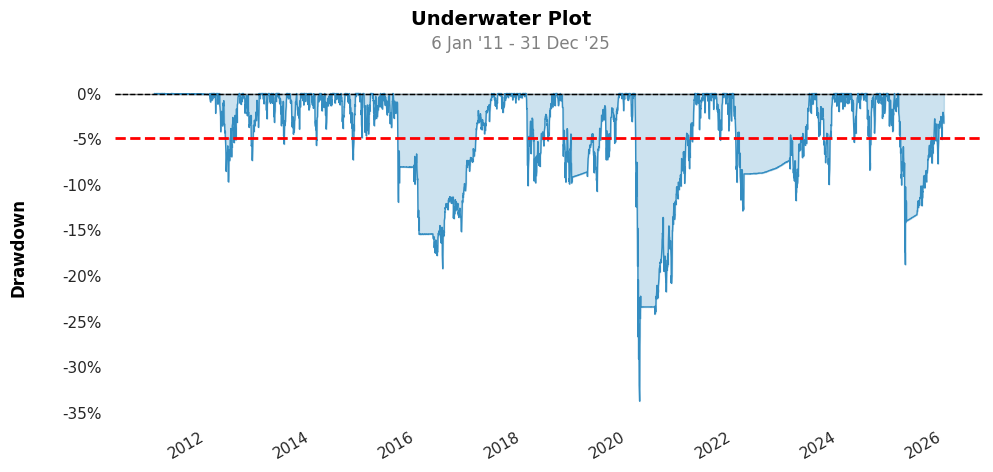

In [8]:
# --- QuantStats standalone plots ---
# Each function generates a single chart. These are the ones
# you will reach for most often in practice.

# 1. Drawdown plot: same as what we built manually in Notebook 7.1,
#    but produced in one line. Shades the underwater periods and
#    labels the worst episodes.
qs.plots.drawdown(strategy_returns, show=True)

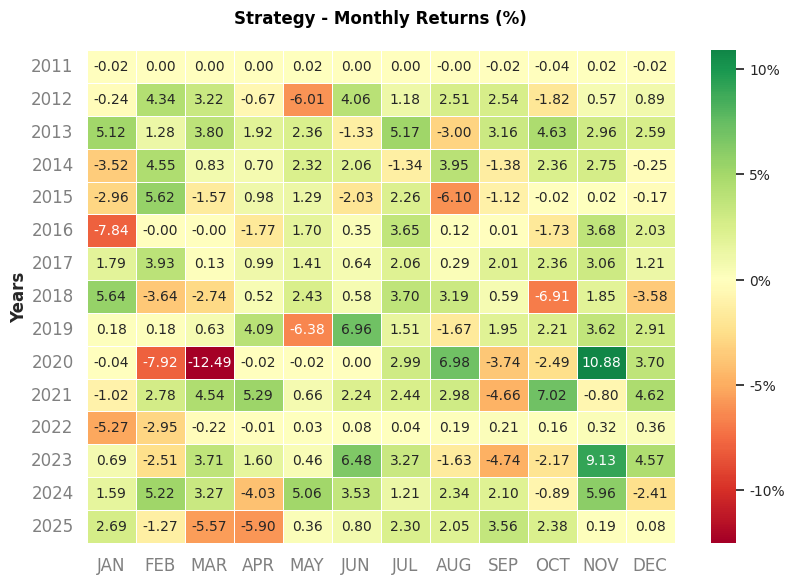

In [9]:
# 2. Monthly returns heatmap: color-coded grid showing performance
#    by month and year. Green is positive, red is negative.
#    Useful for spotting seasonal patterns and identifying
#    which years the strategy struggled.
qs.plots.monthly_heatmap(strategy_returns, show=True)

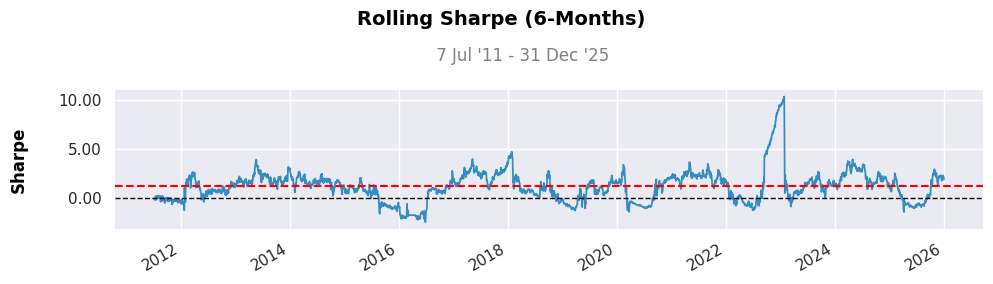

In [10]:
# 3. Rolling Sharpe ratio: similar to what we built in Notebook 7.1,
#    but with the benchmark overlaid for direct comparison.
qs.plots.rolling_sharpe(strategy_returns, show=True)

One line of code for each chart. The drawdown plot, monthly heatmap, and rolling Sharpe are the three you will reach for most often. The heatmap is particularly useful: March 2020 at -12.49% jumps off the page, and the rows of near-zero values in 2011 confirm the strategy was in BIL for most of that year. The rolling Sharpe uses a 6-month window by default (versus the 12-month window we built in Notebook 7.1), which makes it choppier but more responsive to recent performance shifts.

QuantStats has many more plotting functions available. Here are the most useful ones for strategy evaluation:

| What it shows | Function call |
|---|---|
| Cumulative returns vs benchmark | `qs.plots.returns(strategy_returns, benchmark_returns)` |
| Annual return bar chart | `qs.plots.yearly_returns(strategy_returns)` |
| Return distribution histogram | `qs.plots.histogram(strategy_returns)` |
| Daily return bar chart | `qs.plots.daily_returns(strategy_returns)` |
| Rolling volatility | `qs.plots.rolling_volatility(strategy_returns)` |
| Rolling beta vs benchmark | `qs.plots.rolling_beta(strategy_returns, benchmark_returns)` |
| Worst drawdown episodes on equity curve | `qs.plots.drawdowns_periods(strategy_returns)` |
| Log-scale cumulative returns | `qs.plots.log_returns(strategy_returns)` |

All of these accept `show=True` to display inline in a notebook. You can also pass `savefig='filename.png'` to save any chart to disk. Explore them on your own data; the function names are self-explanatory and the output is clean enough for most internal reporting.

## Section 4: Comparing PyFolio and QuantStats

We have now run the same strategy through both libraries. Before moving on, let us consolidate what we learned about each one so you can make an informed choice about which to use and when.

In [12]:
# --- Side-by-side feature comparison ---
# Rather than describing this in prose, a table makes the differences
# immediately scannable.

comparison = {
    'Feature': [
        'Active development',
        'Side-by-side benchmark stats',
        'HTML report export',
        'Standalone metric functions',
        'Standalone plot functions',
        'Tear sheet (all-in-one)',
        'Sharpe methodology',
        'CAGR methodology',
        'Pandas compatibility',
        'Custom risk-free rate',
        'Number of metrics in report',
    ],
    'PyFolio': [
        'No (community fork)',
        'No (strategy only)',
        'No',
        'Limited',
        'No (tear sheet only)',
        'Yes (institutional format)',
        'Arithmetic annualization',
        'Matches manual calc (~9.59%)',
        'Frequent warnings',
        'Yes (treasury_utils)',
        '~15',
    ],
    'QuantStats': [
        'Yes',
        'Yes',
        'Yes (shareable)',
        'Yes (qs.stats module)',
        'Yes (qs.plots module)',
        'Yes (HTML and inline)',
        'Arithmetic annualization',
        'Different convention (~6.51%)',
        'Stable',
        'Yes (rf parameter)',
        '~60',
    ],
}

df_comparison = pd.DataFrame(comparison).set_index('Feature')
print("PyFolio vs QuantStats: Feature Comparison")
print("=" * 90)
print(df_comparison.to_string())

PyFolio vs QuantStats: Feature Comparison
                                                   PyFolio                     QuantStats
Feature                                                                                  
Active development                     No (community fork)                            Yes
Side-by-side benchmark stats            No (strategy only)                            Yes
HTML report export                                      No                Yes (shareable)
Standalone metric functions                        Limited          Yes (qs.stats module)
Standalone plot functions             No (tear sheet only)          Yes (qs.plots module)
Tear sheet (all-in-one)         Yes (institutional format)          Yes (HTML and inline)
Sharpe methodology                Arithmetic annualization       Arithmetic annualization
CAGR methodology              Matches manual calc (~9.59%)  Different convention (~6.51%)
Pandas compatibility                     Frequent warnings

The table makes the practical choice fairly clear.

**For day-to-day work, use QuantStats.** It is actively maintained, shows strategy and benchmark side by side, exports to HTML, and gives you standalone functions for quick calculations. The `qs.stats` module alone justifies the library: one function call to get a single metric without generating a full report.

**For standardized tear sheets, PyFolio still has value.** The institutional format is widely recognized in the quant community. If you are presenting to someone who has seen PyFolio tear sheets before, the format provides instant credibility. It is also the format you will encounter most often in open-source strategy repositories and research blog posts.

**For anything that matters, verify with your own code.** Both libraries produced CAGR values that differed from our manual calculation. Both use arithmetic Sharpe ratio conventions that differ from the geometric approach we built in Notebook 7.1. These are not bugs. They are design choices made by different developers with different conventions. The issue is that neither library warns you about these choices. You see a number, you assume it is correct, and you move on. Now you know better.

A reasonable workflow is: use QuantStats for fast exploration and reporting, cross-check critical metrics with your `calculate_performance_metrics()` function from Notebook 7.1, and save PyFolio for situations where the institutional tear sheet format adds value. Use both when you want a second opinion.

One final note on libraries. PyFolio and QuantStats are two of the better known and more widely used evaluation packages, but they are not the only ones. The Python ecosystem has several alternatives, and new ones appear regularly.

My strong recommendation is to build your own evaluation toolkit over time. Start with the `calculate_performance_metrics()` function we wrote in Notebook 7.1 and expand it as your needs evolve. Add metrics that matter to your specific strategy. Remove ones that do not. Customize the output format so it answers the questions you actually ask when you sit down to evaluate a backtest.

When you build your own tools, you have full control. You know exactly how every number is calculated. You are not surprised by methodology differences. You can create metrics that align with your own trading philosophy rather than relying on whatever a library developer decided was important. The libraries are excellent for quick exploration and sanity checks, but for anything that drives a real decision, you want code you wrote, code you understand, and code you can defend.

## Section 5: Applying to the VIXY Tail Hedge Baseline

Everything so far has used the 50/200 SMA crossover as a teaching example. Now we connect back to our case study. We load the VIXY tail hedge strategy returns (90-day SMA baseline from Chapter 6) and run both libraries against it with SPY as the benchmark. This serves two purposes: it gives us a professional-grade evaluation of the strategy we have been building throughout the book, and it lets us see how a genuinely different strategy profile looks under the same tools.

The crossover strategy was binary: 100% SPY or 100% BIL. The VIXY tail hedge is always 80% SPY, with the remaining 20% split between BIL and VIXY based on the volatility signal. This means it will always trail SPY on total return (the 20% defensive sleeve drags performance in bull markets), but it should show better risk-adjusted metrics and shallower drawdowns. The evaluation libraries will make this comparison straightforward.

In [13]:
# --- Rebuild the VIXY tail hedge strategy returns ---
# Same logic as Notebook 6.4 Section 2.
# We recalculate here so this notebook is self-contained.

# We need all four columns for the VIXY strategy
df_prices_full = pd.read_parquet('case_study_prices.parquet')
df_returns_full = df_prices_full.pct_change().dropna()

# VIX series for signal generation
vix = df_prices_full['^VIX'].copy()

# 90-day SMA of VIX (the baseline filter from Chapters 5-6)
vix_sma_90 = vix.rolling(window=90).mean()

# SPY 10-day annualized realized volatility (in %)
# This is the "trigger" side of the signal: when realized vol exceeds
# the VIX reference, something unusual is happening
spy_returns_full = df_prices_full['SPY'].pct_change()
spy_realized_vol = spy_returns_full.rolling(window=10).std() * np.sqrt(252) * 100

# Signal: hedge ON when realized vol > VIX SMA
signal_on = spy_realized_vol > vix_sma_90

# VIXY allocation when hedge is active: VIX/100, capped at 20%
# When VIX is at 25, VIXY gets 25% of the portfolio... but capped at 20%
# When VIX is at 15, VIXY gets 15%
vixy_alloc = np.where(signal_on, np.minimum(vix / 100, 0.20), 0.0)

# Build daily weights
# SPY is always 80% (the risky portion is constant)
# The remaining 20% is split between VIXY (tail hedge) and BIL (cash)
df_vixy_weights = pd.DataFrame(index=df_prices_full.index)
df_vixy_weights['SPY'] = 0.80
df_vixy_weights['BIL'] = 0.20 - vixy_alloc
df_vixy_weights['VIXY'] = vixy_alloc
df_vixy_weights = df_vixy_weights.dropna()

# --- Calculate portfolio returns using lagged weights ---
# Same process as the crossover strategy: yesterday's weights
# applied to today's asset returns to avoid lookahead bias
common_idx = df_vixy_weights.index.intersection(df_returns_full.index)
w_lagged = df_vixy_weights.loc[common_idx].shift(1).dropna()
r_aligned = df_returns_full[['SPY', 'BIL', 'VIXY']].loc[w_lagged.index]

vixy_strategy_returns = (w_lagged * r_aligned).sum(axis=1)
vixy_strategy_returns.name = 'VIXY_Tail_Hedge'

# SPY buy-and-hold benchmark over the same period
vixy_benchmark_returns = r_aligned['SPY'].copy()
vixy_benchmark_returns.name = 'SPY_Buy_Hold'

print(f"VIXY strategy period: {vixy_strategy_returns.index[0].strftime('%Y-%m-%d')} to "
      f"{vixy_strategy_returns.index[-1].strftime('%Y-%m-%d')}")
print(f"Trading days: {len(vixy_strategy_returns)}")
print(f"Days hedge active: {(w_lagged['VIXY'] > 0).sum()} "
      f"({(w_lagged['VIXY'] > 0).mean():.1%})")

VIXY strategy period: 2011-01-06 to 2025-12-31
Trading days: 3769
Days hedge active: 752 (20.0%)


Same date range and trading day count as the crossover strategy, so comparisons will be on equal footing. The hedge is active 20% of the time, matching what we saw in Notebook 6.4. The other 80% of days, the portfolio is 80% SPY and 20% BIL, which is its neutral allocation.



### 5.1 Recap: How the VIXY Tail Hedge Strategy Works

We have been building this strategy since Chapter 3, so here is a quick refresher on the logic before we evaluate it.

The VIXY tail hedge is a portfolio that is always 80% invested in SPY (the risky portion) with a 20% defensive sleeve. The defensive sleeve switches between BIL (T-bills, essentially cash) and VIXY (a volatility ETF that profits when the VIX spikes) based on a signal. The signal compares two things:

1. **SPY's 10-day realized volatility (annualized):** this measures how much SPY has actually been moving recently. When this number is elevated, the market is already experiencing stress.

2. **The 90-day SMA of VIX:** this is the market's expectation of future volatility, smoothed over roughly one quarter to filter out day-to-day noise.

When realized volatility exceeds the smoothed VIX, something unusual is happening: the market is moving more than the VIX says it should. The strategy interprets this as a signal to put on a tail hedge by moving part of the defensive sleeve from BIL into VIXY. The VIXY allocation is sized by the level of VIX itself (VIX / 100, capped at 20%), so the hedge is larger when volatility is higher.

When the signal is off (most of the time), the portfolio sits at 80% SPY and 20% BIL. This means the strategy will always trail 100% SPY on total return during bull markets because 20% of the capital is earning near-zero in T-bills. That drag is the price of protection. The strategy's value is not in beating SPY on return. It is in delivering smoother returns, shallower drawdowns, and a better Sharpe ratio by reducing the impact of market crashes.

This is a fundamentally different profile from the 50/200 SMA crossover. The crossover was all-or-nothing: 100% SPY or 100% BIL. The VIXY strategy is always partially invested in SPY, which means it participates in every rally (at 80%) and absorbs every decline (also at 80%, but with a potential VIXY offset during crashes). The crossover tried to avoid drawdowns by leaving the market entirely. The VIXY strategy tries to offset drawdowns while staying invested.

Now let us run both libraries on this strategy, starting with PyFolio.

Start date,2011-01-06
End date,2025-12-31
Total months,179
,Backtest
Annual return,10.634%
Cumulative returns,353.343%
Annual volatility,11.373%
Sharpe ratio,0.95
Calmar ratio,0.52
Stability,0.98
Max drawdown,-20.545%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,20.55,2021-11-18,2022-09-30,2023-12-19,544
1,11.46,2018-09-20,2018-12-24,2019-04-01,138
2,10.98,2020-03-17,2020-03-23,2020-03-30,10
3,10.97,2024-08-05,2025-04-07,2025-06-06,220
4,10.45,2011-04-29,2011-08-08,2011-09-14,99


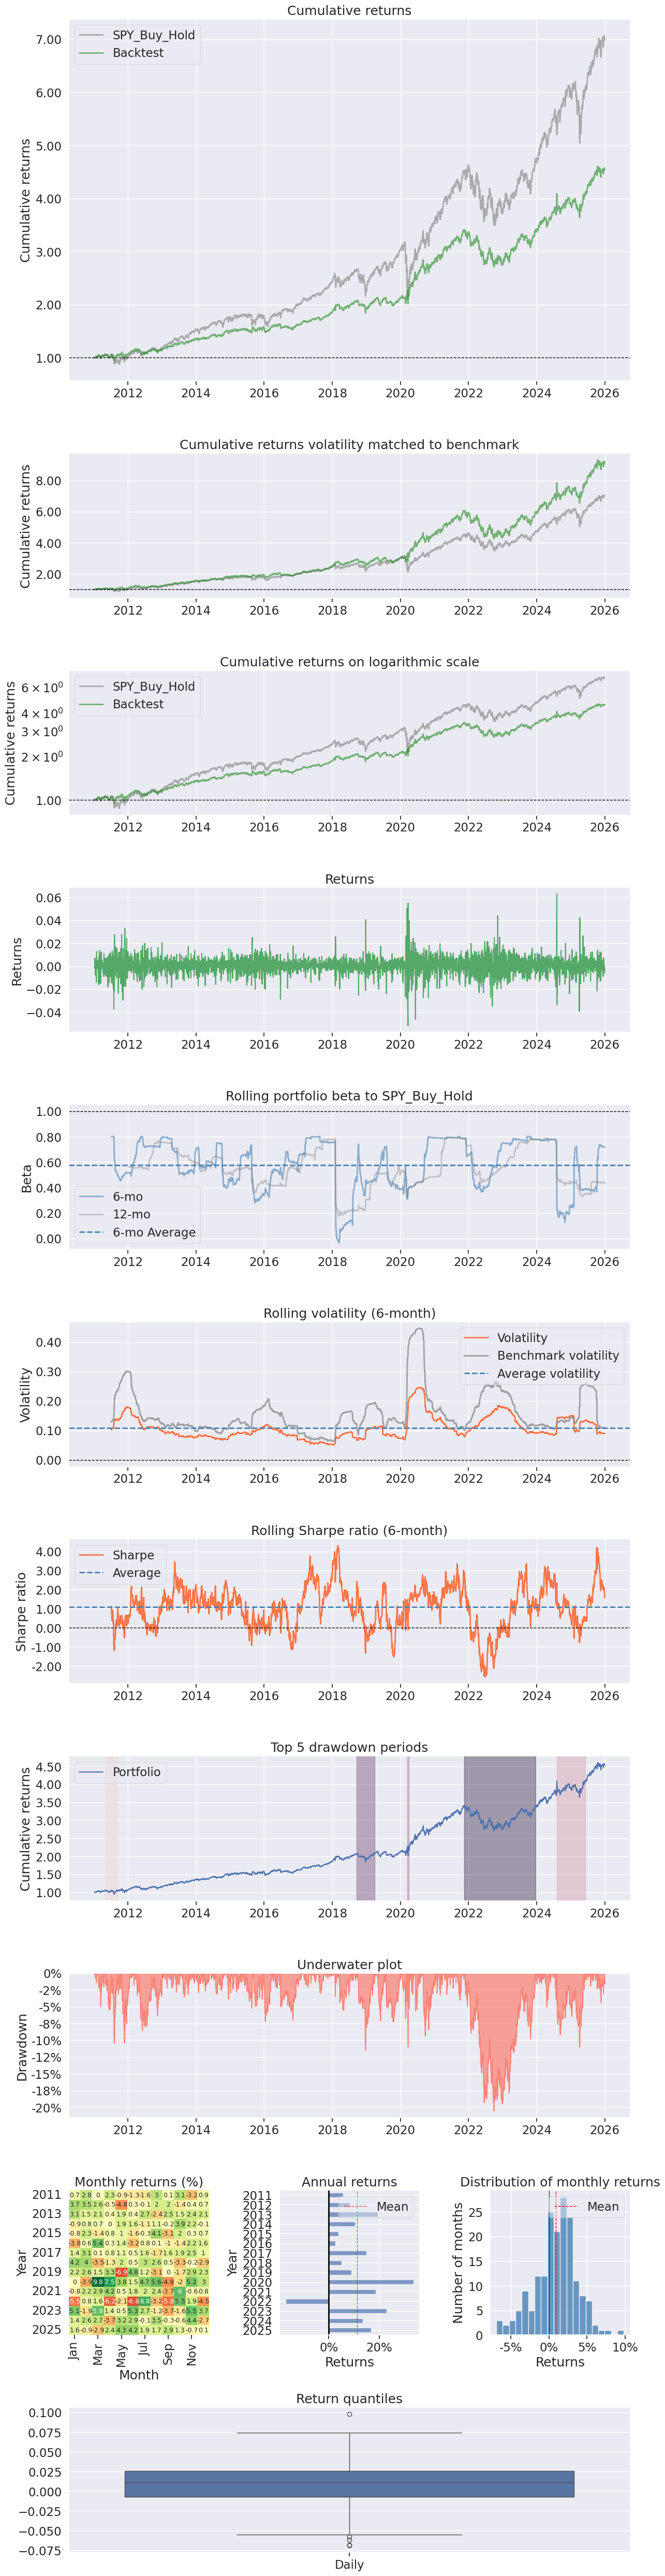

In [14]:
# --- PyFolio tear sheet for the VIXY tail hedge ---
pf.create_returns_tear_sheet(vixy_strategy_returns,
                             benchmark_rets=vixy_benchmark_returns)

### 5.2 VIXY Tail Hedge: PyFolio Results

The difference in strategy profile is striking. Compare these numbers to the crossover strategy we evaluated earlier in this notebook.

**Returns and risk:** The VIXY strategy earned an annualized return of 10.63% with a volatility of 11.37%. The crossover earned 9.59% with a volatility of 13.82%. The VIXY strategy made more money and took less risk. That combination is rare.

**Risk-adjusted metrics:** The Sharpe ratio of 0.95 is a significant improvement over the crossover's 0.73 and comfortably above SPY buy-and-hold's 0.84. The Sortino ratio of 1.38 (versus the crossover's 1.02) confirms that the advantage is not just lower total volatility but specifically lower downside volatility. The Calmar ratio of 0.52 versus the crossover's 0.28 tells the same story from the drawdown side.

**Maximum drawdown is where the VIXY strategy earns its keep.** The worst drawdown was -20.55%, compared to -33.72% for both the crossover and SPY. And look at when it happened: the worst episode was not COVID. It was the 2021-2022 grinding decline, which took 544 days from peak to recovery. COVID shows up as the third-worst episode at only -10.98%, lasting just 10 trading days peak to trough and recovering in 3 days. The VIXY hedge did exactly what it was designed to do during the crash that destroyed the crossover strategy.

**The underwater plot tells the full story.** Compare it to the crossover's drawdown chart. The VIXY strategy's worst trough barely touches -20%, whereas the crossover plunged to -34%. The drawdown chart is visibly shallower across the entire 15-year period, not just during COVID.

**Skew flipped positive.** The crossover had a skew of -0.51 (fat left tail, meaning occasional large losses). The VIXY strategy has a skew of +0.13. This is remarkable. Positive skew means the return distribution is slightly tilted toward large gains rather than large losses. The VIXY hedge is converting some of the market's negative skew into a more symmetric (or even slightly positive) return profile. Kurtosis dropped from 27.30 to 7.43 as well, meaning fewer extreme days in both directions.

**The volatility-matched cumulative returns chart (second from top) is the most telling visual.** It scales the strategy's returns to match SPY's volatility, answering: if you leveraged this strategy up to take the same risk as SPY, what would you have earned? The VIXY strategy line finishes above SPY. That means the strategy produces more return per unit of risk, which is exactly what the Sharpe ratio of 0.95 versus 0.808 was telling us in number form.

**Beta of 0.52** means the strategy captures about half of SPY's daily moves. Lower than the crossover's 0.65, because the VIXY strategy is always only 80% in SPY (versus the crossover which was 100% SPY or 100% BIL). The alpha of 0.03 is small but positive, meaning the strategy produces a modest return above what its market exposure alone would predict. The crossover's alpha was effectively zero.

This is the difference between a strategy that tries to avoid risk by leaving the market (the crossover) and one that tries to offset risk while staying invested (the VIXY tail hedge). The crossover missed rallies. The VIXY strategy participated in every rally at 80% and cushioned the crashes with the volatility hedge.

Now let us see the same strategy through QuantStats.

In [15]:
# --- QuantStats standalone metrics for the VIXY tail hedge ---
# We use the standalone functions rather than generating another
# full HTML report. The reader can generate the HTML on their own.

print("QuantStats Metrics: VIXY Tail Hedge vs SPY Buy & Hold")
print("=" * 65)
print(f"{'Metric':<28} {'VIXY Tail Hedge':>18} {'SPY Buy & Hold':>17}")
print("-" * 65)

# Return metrics
print(f"{'Cumulative return':<28} "
      f"{qs.stats.comp(vixy_strategy_returns):>17.2%} "
      f"{qs.stats.comp(vixy_benchmark_returns):>17.2%}")
print(f"{'CAGR':<28} "
      f"{qs.stats.cagr(vixy_strategy_returns):>17.2%} "
      f"{qs.stats.cagr(vixy_benchmark_returns):>17.2%}")

# Risk metrics
print(f"{'Volatility (ann.)':<28} "
      f"{qs.stats.volatility(vixy_strategy_returns):>17.2%} "
      f"{qs.stats.volatility(vixy_benchmark_returns):>17.2%}")
print(f"{'Max drawdown':<28} "
      f"{qs.stats.max_drawdown(vixy_strategy_returns):>17.2%} "
      f"{qs.stats.max_drawdown(vixy_benchmark_returns):>17.2%}")

# Risk-adjusted metrics
print(f"{'Sharpe':<28} "
      f"{qs.stats.sharpe(vixy_strategy_returns, rf=0):>17.3f} "
      f"{qs.stats.sharpe(vixy_benchmark_returns, rf=0):>17.3f}")
print(f"{'Sortino':<28} "
      f"{qs.stats.sortino(vixy_strategy_returns, rf=0):>17.3f} "
      f"{qs.stats.sortino(vixy_benchmark_returns, rf=0):>17.3f}")
print(f"{'Calmar':<28} "
      f"{qs.stats.calmar(vixy_strategy_returns):>17.3f} "
      f"{qs.stats.calmar(vixy_benchmark_returns):>17.3f}")

QuantStats Metrics: VIXY Tail Hedge vs SPY Buy & Hold
Metric                          VIXY Tail Hedge    SPY Buy & Hold
-----------------------------------------------------------------
Cumulative return                      353.34%           598.37%
CAGR                                     7.21%             9.36%
Volatility (ann.)                       11.37%            17.17%
Max drawdown                           -20.55%           -33.72%
Sharpe                                   0.946             0.843
Sortino                                  1.384             1.186
Calmar                                   0.351             0.278


### 5.3 VIXY Tail Hedge: QuantStats Results

The same patterns we saw with the crossover strategy appear here. QuantStats and PyFolio agree on cumulative return (353.34%), volatility (11.37%), max drawdown (-20.55%), and Sharpe (0.95 vs 0.946, the difference is rounding). The CAGR discrepancy reappears: QuantStats reports 7.21% while PyFolio reported 10.63%. Same issue, same cause, same lesson.

What matters is the comparison against SPY, and on that front every risk-adjusted metric favors the VIXY strategy. Sharpe of 0.946 versus 0.843 for SPY. Sortino of 1.384 versus 1.186. Calmar of 0.351 versus 0.278. Maximum drawdown of -20.55% versus -33.72%. The strategy earned less total return (353% vs 598%), and you could reasonably argue that the return drag is too high a price for the protection. But the risk-adjusted numbers say the tradeoff is favorable: you gave up roughly 35% of SPY's cumulative return and cut the worst drawdown by nearly 40%.

Compare the VIXY strategy to the crossover strategy across both libraries:

| Metric | 50/200 Crossover | VIXY Tail Hedge | SPY Buy & Hold |
|---|---|---|---|
| Cumulative return | 293% | 353% | 598% |
| Max drawdown | -33.72% | -20.55% | -33.72% |
| Sharpe (PyFolio) | 0.73 | 0.95 | 0.84 |
| Sortino (PyFolio) | 1.02 | 1.38 | 1.19 |
| Calmar (PyFolio) | 0.28 | 0.52 | 0.28 |

The VIXY tail hedge beats the crossover on every single metric: higher return, lower drawdown, better Sharpe, better Sortino, better Calmar. It also beats SPY on every risk-adjusted metric while delivering meaningfully lower drawdowns. The crossover failed to beat SPY on any metric. The VIXY strategy fails only on total return, which is by design: the 20% defensive allocation will always drag total return in bull markets.

This is the difference between a strategy with a sound economic rationale (volatility hedging during stress periods) and a purely mechanical signal (moving average crossover). Both are simple to implement. Only one of them works.

In the chapter text, we will revisit the Notebook 6.4 filter comparison results using the evaluation framework you have learned in this chapter. The question there is not whether the VIXY strategy works (it clearly does), but whether replacing the 90-day SMA with a Kalman filter or other signal processing technique makes it work better. As you will see, that is a much harder question to answer.